In [4]:
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline") 
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())  

inline


<xarray.Dataset> Size: 14MB
Dimensions:      (time: 552, lat: 51, lon: 41)
Coordinates:
  * time         (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01...
  * lat          (lat) float64 408B 25.0 25.5 26.0 26.5 ... 48.5 49.0 49.5 50.0
  * lon          (lon) float64 328B -90.0 -89.38 -88.75 ... -66.25 -65.62 -65.0
Data variables:
    NET_TOA_CLR  (time, lat, lon) float32 5MB ...
    NET_SFC_CLR  (time, lat, lon) float32 5MB ...
    TS           (time, lat, lon) float32 5MB ...
Attributes:
    title:             MERRA-2 Eastern US clear-sky net TOA flux, net surface...
    source_directory:  /scratch/sjacker2/project_data
    note:              NET_TOA_CLR = SWTNTCLR - LWTUPCLR; NET_SFC_CLR = SWGNT...
<xarray.Dataset> Size: 13kB
Dimensions:    (time: 552)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-01T00:30:00 ... 2025-12-01T0...
Data variables:
    PM25_mean  (time) float64 4kB ...
    T2M_mean   (time) float64 4kB ...
Attributes:
    title:         Month

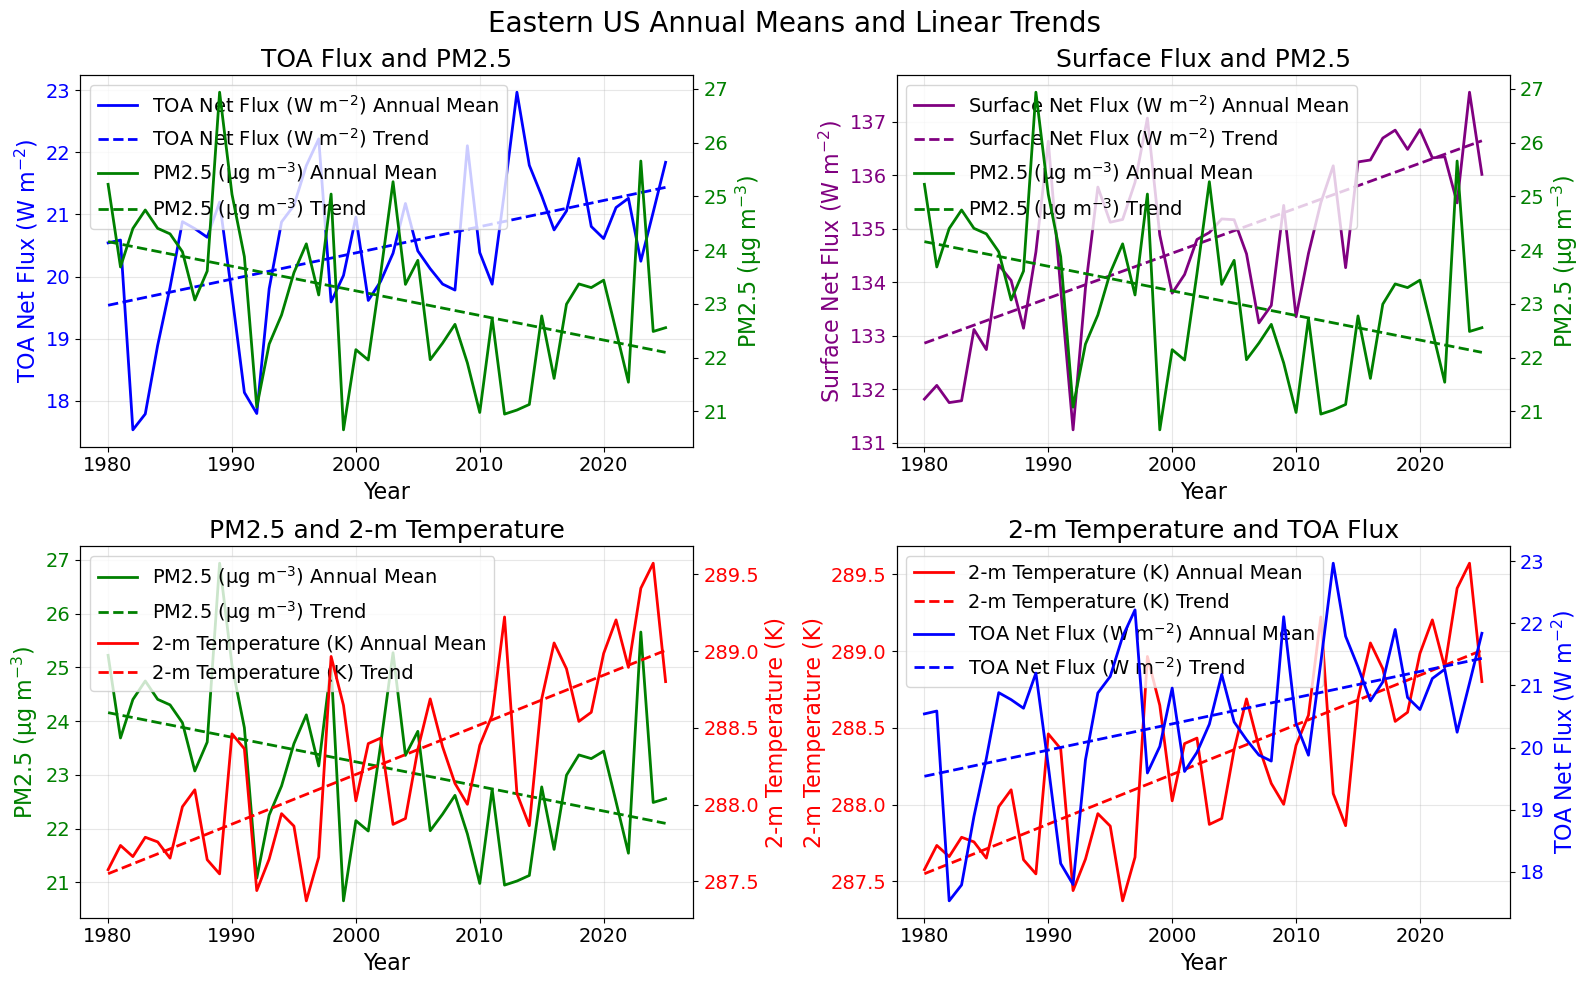

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

#file paths
flux_file = "/scratch/sjacker2/project_data/merra2_eastern_us_fluxes_ts_combined.nc"
pm25_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means.nc"

#open datasets
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_file)

#check it's only 1980–2025
ds_flux = ds_flux.sel(time=slice("1980-01-01", "2025-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2025-12-31"))
print(ds_flux)
print(ds_pm)

#fluxes aren't regional means yet so area-weight them
weights = np.cos(np.deg2rad(ds_flux["lat"]))
weights.name = "weights"
toa_ts = ds_flux["NET_TOA_CLR"].weighted(weights).mean(dim=("lat", "lon"))
sfc_ts = ds_flux["NET_SFC_CLR"].weighted(weights).mean(dim=("lat", "lon"))

#already area-weighted by process_aer_slv.py
pm25_ts = ds_pm["PM25_mean"]
t2m_ts = ds_pm["T2M_mean"]

#compute annual means so seasonal variation doesn't get in the way
toa_annual = toa_ts.groupby("time.year").mean()
sfc_annual = sfc_ts.groupby("time.year").mean()
pm25_annual = pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

years = toa_annual["year"].values.astype(float)

#fit linear trends
toa_coeffs = np.polyfit(years, toa_annual.values, 1)
sfc_coeffs = np.polyfit(years, sfc_annual.values, 1)
pm25_coeffs = np.polyfit(years, pm25_annual.values, 1)
t2m_coeffs = np.polyfit(years, t2m_annual.values, 1)

toa_trendline = np.polyval(toa_coeffs, years)
sfc_trendline = np.polyval(sfc_coeffs, years)
pm25_trendline = np.polyval(pm25_coeffs, years)
t2m_trendline = np.polyval(t2m_coeffs, years)

#print trends
print("Annual-mean trends")
print("------------------")
print(f"TOA flux:     {toa_coeffs[0]:.4f} W m^-2/year")
print(f"TOA flux:     {toa_coeffs[0]*10:.4f} W m^-2/decade")
print()
print(f"Surface flux: {sfc_coeffs[0]:.4f} W m^-2/year")
print(f"Surface flux: {sfc_coeffs[0]*10:.4f} W m^-2/decade")
print()
print(f"PM2.5:        {pm25_coeffs[0]:.4f} µg m^-3/year")
print(f"PM2.5:        {pm25_coeffs[0]*10:.4f} µg m^-3/decade")
print()
print(f"T2M:          {t2m_coeffs[0]:.4f} K/year")
print(f"T2M:          {t2m_coeffs[0]*10:.4f} K/decade")


#function to plot each panel
def make_dual_panel(ax, years, left_data, left_trend, right_data, right_trend,
                    left_label, right_label, left_color, right_color, title):
    #left axis
    l1 = ax.plot(years, left_data, color=left_color, linewidth=2, label=f"{left_label} Annual Mean")
    l2 = ax.plot(years, left_trend, color=left_color, linestyle="--", linewidth=2, label=f"{left_label} Trend")
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel(left_label, fontsize=16, color=left_color)
    ax.tick_params(axis="y", labelcolor=left_color, labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    ax.grid(True, alpha=0.3)

    #right axis
    axr = ax.twinx()
    l3 = axr.plot(years, right_data, color=right_color, linewidth=2, label=f"{right_label} Annual Mean")
    l4 = axr.plot(years, right_trend, color=right_color, linestyle="--", linewidth=2, label=f"{right_label} Trend")
    axr.set_ylabel(right_label, fontsize=16, color=right_color)
    axr.tick_params(axis="y", labelcolor=right_color, labelsize=14)

    #combined legend
    lines = l1 + l2 + l3 + l4
    labels = [line.get_label() for line in lines]
    ax.legend(lines, labels, loc="upper left", frameon=True, fontsize=14)

    ax.set_title(title, fontsize=18)


#create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#Panel 1 is TOA flux + PM2.5
make_dual_panel(
    axes[0, 0], years,
    toa_annual, toa_trendline,
    pm25_annual, pm25_trendline,
    "TOA Net Flux (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "blue", "green",
    "TOA Flux and PM2.5"
)

#Panel 2 is Surface flux + PM2.5
make_dual_panel(
    axes[0, 1], years,
    sfc_annual, sfc_trendline,
    pm25_annual, pm25_trendline,
    "Surface Net Flux (W m$^{-2}$)", "PM2.5 (µg m$^{-3}$)",
    "purple", "green",
    "Surface Flux and PM2.5"
)

#Panel 3 is PM2.5 + 2-m temperature
make_dual_panel(
    axes[1, 0], years,
    pm25_annual, pm25_trendline,
    t2m_annual, t2m_trendline,
    "PM2.5 (µg m$^{-3}$)", "2-m Temperature (K)",
    "green", "red",
    "PM2.5 and 2-m Temperature"
)

#Panel 4 is 2-m temperature + TOA flux
make_dual_panel(
    axes[1, 1], years,
    t2m_annual, t2m_trendline,
    toa_annual, toa_trendline,
    "2-m Temperature (K)", "TOA Net Flux (W m$^{-2}$)",
    "red", "blue",
    "2-m Temperature and TOA Flux"
)

plt.suptitle("Eastern US Annual Means and Linear Trends", fontsize=20)
plt.tight_layout()
plt.show()

PM2.5 trend: -0.0458 µg m^-3/year
PM2.5 trend: -0.4575 µg m^-3/decade

T2M trend:   0.0323 K/year
T2M trend:   0.3234 K/decade


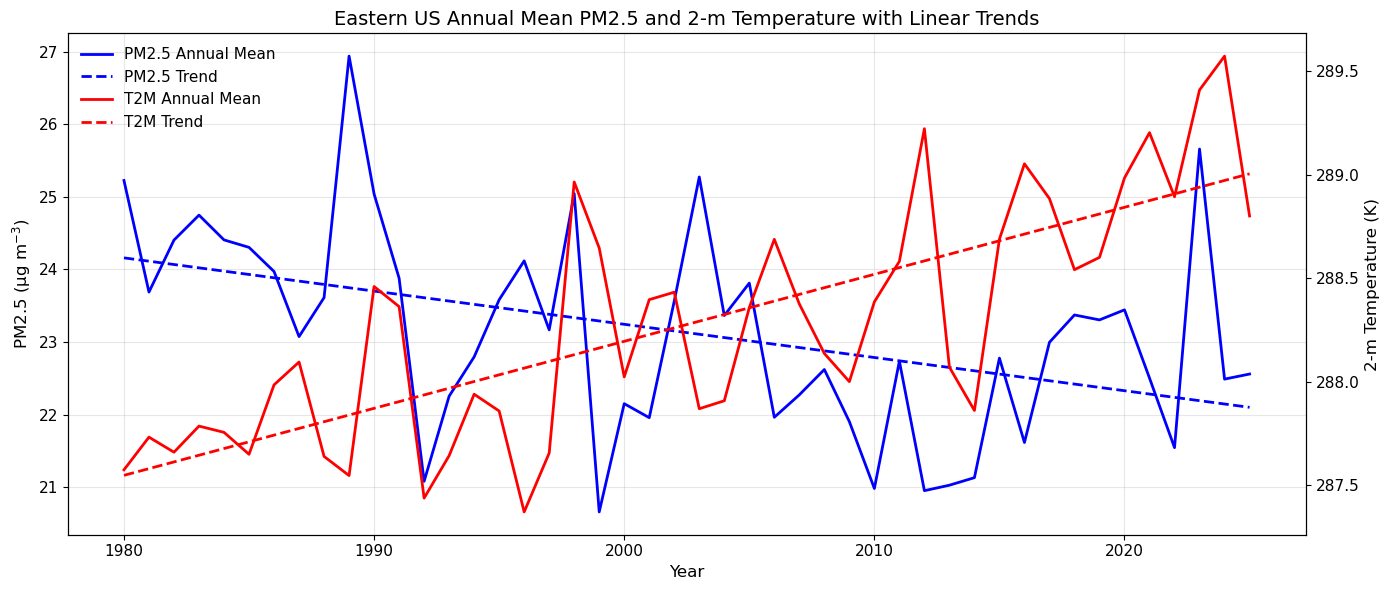

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


nc_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_means.nc"


ds = xr.open_dataset(nc_file)


pm25_ts = ds["PM25_mean"]
t2m_ts = ds["T2M_mean"]


pm25_annual = pm25_ts.groupby("time.year").mean()
t2m_annual = t2m_ts.groupby("time.year").mean()

years = pm25_annual["year"].values.astype(float)


pm25_coeffs = np.polyfit(years, pm25_annual.values, 1)
t2m_coeffs = np.polyfit(years, t2m_annual.values, 1)

pm25_trendline = np.polyval(pm25_coeffs, years)
t2m_trendline = np.polyval(t2m_coeffs, years)


pm25_trend_per_year = pm25_coeffs[0]
t2m_trend_per_year = t2m_coeffs[0]

pm25_trend_decade = pm25_trend_per_year * 10
t2m_trend_decade = t2m_trend_per_year * 10

print(f"PM2.5 trend: {pm25_trend_per_year:.4f} µg m^-3/year")
print(f"PM2.5 trend: {pm25_trend_decade:.4f} µg m^-3/decade")
print()
print(f"T2M trend:   {t2m_trend_per_year:.4f} K/year")
print(f"T2M trend:   {t2m_trend_decade:.4f} K/decade")

fig, ax1 = plt.subplots(figsize=(14, 6))

l1 = ax1.plot(years, pm25_annual, label="PM2.5 Annual Mean", linewidth=2, color="blue")
l2 = ax1.plot(years, pm25_trendline, linestyle="--", linewidth=2, label="PM2.5 Trend", color="blue")
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("PM2.5 (µg m$^{-3}$)", fontsize=12)
ax1.tick_params(axis="y", labelsize=11)
ax1.tick_params(axis="x", labelsize=11)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
l3 = ax2.plot(years, t2m_annual, label="T2M Annual Mean", linewidth=2, color="red")
l4 = ax2.plot(years, t2m_trendline, linestyle="--", linewidth=2, label="T2M Trend", color="red")
ax2.set_ylabel("2-m Temperature (K)", fontsize=12)
ax2.tick_params(axis="y", labelsize=11)

lines = l1 + l2 + l3 + l4
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left", frameon=False, fontsize=11)

plt.title("Eastern US Annual Mean PM2.5 and 2-m Temperature with Linear Trends", fontsize=14)
plt.tight_layout()
plt.show()